# 🏠 House Price Prediction with Linear Regression

## Project Objective

The objective of this project is to build and evaluate a Linear Regression
model that predicts house prices based on different property features.

The project involves data exploration, data cleaning, feature selection,
categorical encoding, model training, evaluation, and interpretation.

## Dataset

The dataset contains information about residential properties, including
house prices, number of bedrooms, bathrooms, living area, lot size, floors,
waterfront status, view, condition, construction year, renovation year,
and location.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
df = pd.read_csv("house_price_Dataset.csv")

In [5]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,5/2/2014 0:00,313000.0,3,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,5/2/2014 0:00,2384000.0,5,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,5/2/2014 0:00,342000.0,3,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,5/2/2014 0:00,420000.0,3,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,5/2/2014 0:00,550000.0,4,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [6]:
df.shape

(4600, 18)

In [7]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   str    
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   int64  
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   str    
 15  city           4600 non-null   str    
 16  statezip       4600 non-null   str    
 17  country        4600 non-null   str    
dtypes: float64(3), int6

In [9]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [10]:
df.isnull().sum()

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["price"].describe()

count    4.600000e+03
mean     5.519630e+05
std      5.638347e+05
min      0.000000e+00
25%      3.228750e+05
50%      4.609435e+05
75%      6.549625e+05
max      2.659000e+07
Name: price, dtype: float64

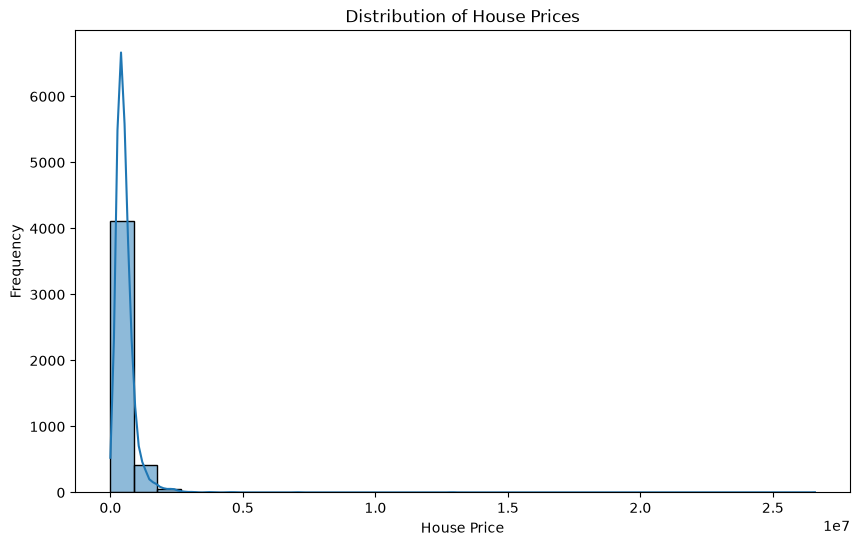

In [13]:
plt.figure(figsize=(10, 6))

sns.histplot(df["price"], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Frequency")

plt.show()

In [14]:
df["city"].nunique()

44

In [15]:
df["country"].nunique()

1

In [16]:
df["statezip"].nunique()

77

In [17]:
df["street"].nunique()

4525

In [18]:
df["city"].value_counts().head(10)

city
Seattle        1573
Renton          293
Bellevue        286
Redmond         235
Kirkland        187
Issaquah        187
Kent            185
Auburn          176
Sammamish       175
Federal Way     148
Name: count, dtype: int64

## Feature Selection

The target variable for this project is `price`.

The potential predictor variables include `bedrooms`, `bathrooms`, `sqft_living`,
`sqft_lot`, `floors`, `waterfront`, `view`, `condition`, `sqft_above`,
`sqft_basement`, `yr_built`, and `yr_renovated`.

These features were selected because characteristics such as the size of the
property, number of bedrooms and bathrooms, number of floors, condition,
waterfront access, and age of the property can influence house prices.

The categorical variables `street`, `city`, `statezip`, and `country` may also
contain useful information. These variables will be converted into numerical
format using One-Hot Encoding before being used in the regression model.

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df["price"].describe()

count    4.600000e+03
mean     5.519630e+05
std      5.638347e+05
min      0.000000e+00
25%      3.228750e+05
50%      4.609435e+05
75%      6.549625e+05
max      2.659000e+07
Name: price, dtype: float64

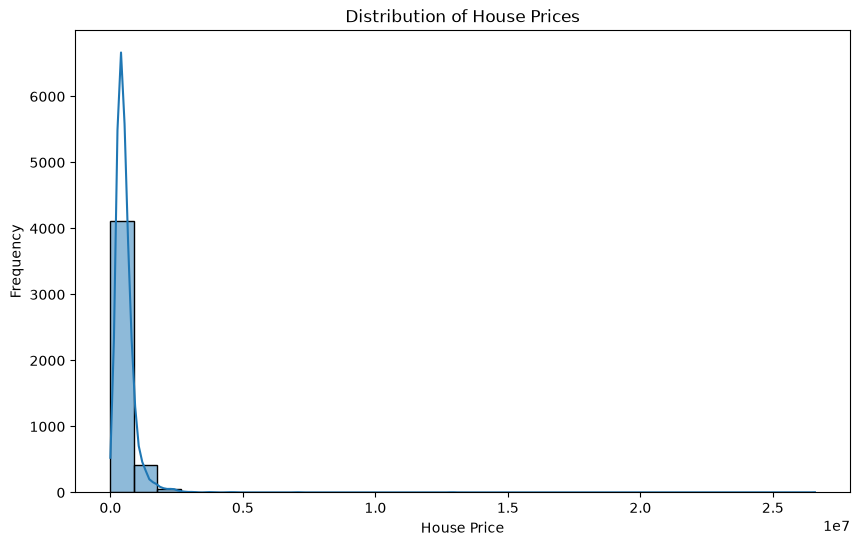

In [21]:
plt.figure(figsize=(10, 6))
sns.histplot(df["price"], bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Frequency")
plt.show()

In [22]:
df["city"].nunique()
df["country"].nunique()
df["statezip"].nunique()
df["street"].nunique()

4525

In [23]:
correlation = df.select_dtypes(include=np.number).corr()

correlation["price"].sort_values(ascending=False)

price            1.000000
sqft_living      0.430410
sqft_above       0.367570
bathrooms        0.327110
view             0.228504
sqft_basement    0.210427
bedrooms         0.200336
floors           0.151461
waterfront       0.135648
sqft_lot         0.050451
condition        0.034915
yr_built         0.021857
yr_renovated    -0.028774
Name: price, dtype: float64

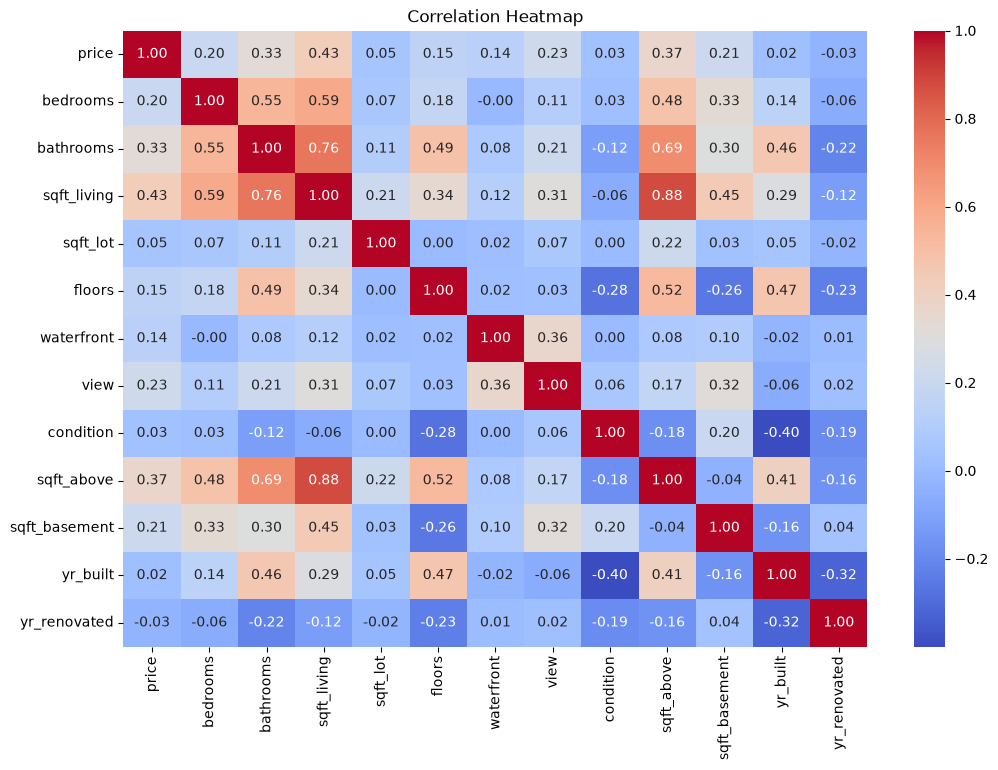

In [24]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [25]:
correlation["price"].sort_values(ascending=False)

price            1.000000
sqft_living      0.430410
sqft_above       0.367570
bathrooms        0.327110
view             0.228504
sqft_basement    0.210427
bedrooms         0.200336
floors           0.151461
waterfront       0.135648
sqft_lot         0.050451
condition        0.034915
yr_built         0.021857
yr_renovated    -0.028774
Name: price, dtype: float64

## Correlation Analysis

The correlation analysis shows that `sqft_living` has the strongest positive
correlation with house price, with a correlation coefficient of approximately
0.43. This suggests that houses with larger living areas tend to have higher
prices.

Other variables with relatively notable positive correlations include
`sqft_above` (0.37) and `bathrooms` (0.33). Variables such as `view`,
`sqft_basement`, and `bedrooms` also show positive relationships with price.

On the other hand, `yr_renovated` has a very weak negative correlation with
price (-0.03), while `yr_built` and `condition` have very weak positive
correlations.

Although correlation provides useful insight into the relationships between
the numerical variables and price, the final feature selection will consider
the potential predictive value of the variables rather than relying only on
correlation coefficients.

In [26]:
df["city"].value_counts().head(10)

city
Seattle        1573
Renton          293
Bellevue        286
Redmond         235
Kirkland        187
Issaquah        187
Kent            185
Auburn          176
Sammamish       175
Federal Way     148
Name: count, dtype: int64

In [27]:
df["statezip"].value_counts().head(10)

statezip
WA 98103    148
WA 98052    135
WA 98117    132
WA 98115    130
WA 98006    110
WA 98059    106
WA 98042    100
WA 98034     99
WA 98074     98
WA 98053     98
Name: count, dtype: int64

In [28]:
df["country"].value_counts()

country
USA    4600
Name: count, dtype: int64

In [29]:
df["street"].nunique()

4525

In [30]:
df = df.drop(columns=["street", "country"])

In [31]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'city', 'statezip'],
      dtype='str')

In [32]:
df["date"].head()

0    5/2/2014 0:00
1    5/2/2014 0:00
2    5/2/2014 0:00
3    5/2/2014 0:00
4    5/2/2014 0:00
Name: date, dtype: str

In [33]:
df["date"].nunique()

70

In [34]:
df["date"] = pd.to_datetime(df["date"])

In [35]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

In [36]:
df[["date", "year", "month"]].head()

,date,year,month
0,2014-05-02,2014,5
1,2014-05-02,2014,5
2,2014-05-02,2014,5
3,2014-05-02,2014,5
4,2014-05-02,2014,5


In [37]:
df = df.drop(columns=["date"])

In [38]:
df = pd.get_dummies(
    df,
    columns=["city", "statezip"],
    drop_first=True
)

In [39]:
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,...,statezip_WA 98155,statezip_WA 98166,statezip_WA 98168,statezip_WA 98177,statezip_WA 98178,statezip_WA 98188,statezip_WA 98198,statezip_WA 98199,statezip_WA 98288,statezip_WA 98354
0,313000.0,3,1.50,1340,7912,1.5,0,0,3,1340,...,False,False,False,False,False,False,False,False,False,False
1,2384000.0,5,2.50,3650,9050,2.0,0,4,5,3370,...,False,False,False,False,False,False,False,False,False,False
2,342000.0,3,2.00,1930,11947,1.0,0,0,4,1930,...,False,False,False,False,False,False,False,False,False,False
3,420000.0,3,2.25,2000,8030,1.0,0,0,4,1000,...,False,False,False,False,False,False,False,False,False,False
4,550000.0,4,2.50,1940,10500,1.0,0,0,4,1140,...,False,False,False,False,False,False,False,False,False,False


In [40]:
df.shape

(4600, 134)

In [41]:
df.isnull().sum().sum()

np.int64(0)

In [42]:
(df["price"] <= 0).sum()

np.int64(49)

In [43]:
df = df[df["price"] > 0]

In [44]:
df.shape

(4551, 134)

In [45]:
(df["price"] <= 0).sum()

np.int64(0)

In [46]:
X = df.drop(columns=["price"])
y = df["price"]

In [47]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4551, 133)
y shape: (4551,)


In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [49]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (3640, 133)
X_test: (911, 133)
y_train: (3640,)
y_test: (911,)


In [50]:
model = LinearRegression()

In [51]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](133,)","[-30560.3 , 35489.81, 124.94,...,353676.98,-46111.2 , 21010.21]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](133,)","['bedrooms','bathrooms','sqft_living',...,'statezip_WA 98199', 'statezip_WA 98288','statezip_WA 98354']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-5.076e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,133
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(93)


In [52]:
y_pred = model.predict(X_test)

In [53]:
y_pred[:10]

array([1279593.82968625,  568383.972543  ,  555364.15956101,
        253188.04886216,  626082.82681998,  405604.75384064,
        307642.6632937 ,  288861.17097989,  449944.96128469,
        857831.86233534])

In [54]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Squared Error (MSE): 45122670700.86877
Root Mean Squared Error (RMSE): 212420.97519046644
R² Score: 0.6966958916223555


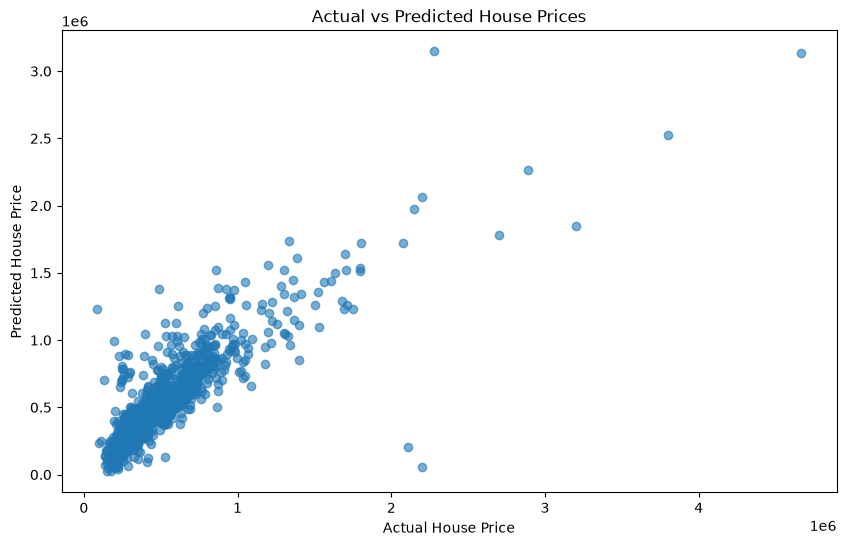

In [55]:
plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [57]:
residuals = y_test - y_pred

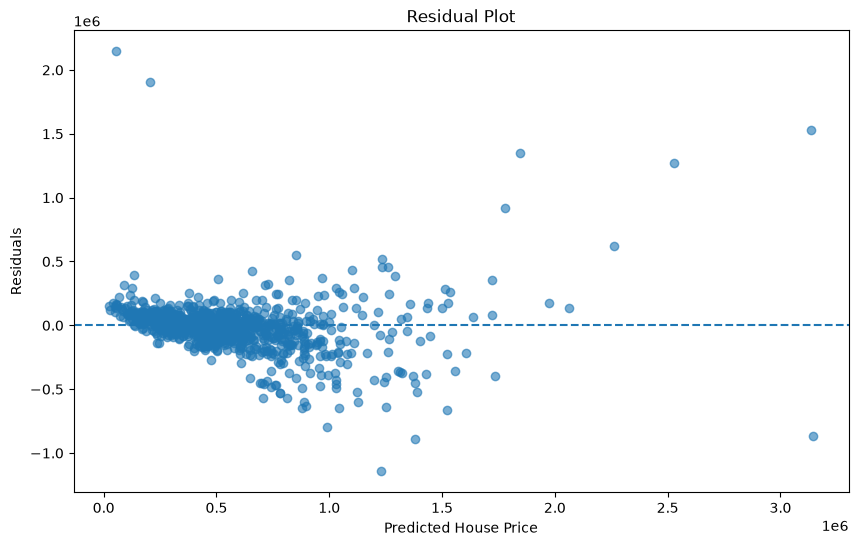

In [58]:
plt.figure(figsize=(10, 6))

plt.scatter(y_pred, residuals, alpha=0.6)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted House Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [59]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

coefficients.head(10)

,Feature,Coefficient
5,waterfront,574355.508330
59,statezip_WA 98004,542244.017871
80,statezip_WA 98039,533736.075080
35,city_Medina,533736.075080
75,statezip_WA 98031,383220.769435
130,statezip_WA 98199,353676.977499
109,statezip_WA 98112,338640.737115
114,statezip_WA 98119,287599.153168
108,statezip_WA 98109,285562.739419
21,city_Clyde Hill,259371.326022


In [60]:
coefficients.tail(10)

,Feature,Coefficient
74,statezip_WA 98030,-131615.982325
123,statezip_WA 98155,-134682.917972
27,city_Federal Way,-141018.917289
82,statezip_WA 98042,-155710.991622
121,statezip_WA 98146,-159724.507304
105,statezip_WA 98106,-169955.138191
76,statezip_WA 98032,-171321.404774
14,city_Auburn,-178212.735060
107,statezip_WA 98108,-178215.766262
127,statezip_WA 98178,-279365.351106


## Conclusion

A Linear Regression model was developed to predict house prices using property
characteristics and location-related features.

The model achieved an R² score of approximately 0.697, meaning that the model
explains about 69.7% of the variation in house prices in the test dataset.

The model had a Mean Squared Error (MSE) of approximately 45.12 billion and a
Root Mean Squared Error (RMSE) of approximately $212,421.

The Actual vs Predicted plot showed a positive relationship between the actual
and predicted house prices. The residual plot showed the prediction errors
scattered around the zero line.

Overall, the Linear Regression model provides a reasonable baseline for house
price prediction. However, its performance could potentially be improved by
using additional feature engineering, transforming skewed variables, handling
outliers, or applying other regression algorithms such as Ridge and Lasso
Regression.